In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("Dataset loaded successfully!")

Saving mobiles_data.csv to mobiles_data (1).csv
Dataset loaded successfully!


In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

Number of rows: 4000
Number of columns: 17

Column names:
['name', 'url', 'release_date', 'spec_score', 'image_url', 'processor', 'ram_storage', 'rear_camera', 'front_camera', 'battery', 'display', 'antutu_score', 'awards', 'user_rating', 'expert_rating', 'price', 'store']


In [4]:
df.head()

,name,url,release_date,spec_score,image_url,processor,ram_storage,rear_camera,front_camera,battery,display,antutu_score,awards,user_rating,expert_rating,price,store
0,Xiaomi Redmi Turbo 5,https://www.91mobiles.com/xiaomi-redmi-turbo-5...,"Release Date:19 Jun, 2026",89%,https://www.91-img.com/pictures/170299-v4-xiao...,MediaTek Dimensity 8500 Ultra,8 GB RAM | 256 GB Storage,50 MP + 8 MP Rear Camera,20 MP Front Camera,7540 mAh | 100W Hyper Charging,6.59 inches (16.74 cm) | AMOLED,"AnTuTu Score 2,135,669","Best Phones Under Rs. 40,000",8.4/10,NaN,"₹37,999",Amazon
1,vivo X300 FE,https://www.91mobiles.com/vivo-x300-fe-price-i...,"Release Date:06 May, 2026",95%,https://www.91-img.com/pictures/173008-v4-vivo...,Snapdragon 8 Gen 5,12 GB RAM | 256 GB Storage,50 MP + 50 MP + 8 MP Rear Camera,50 MP Front Camera,6500 mAh | 90W Flash Charging,6.31 inches (16.03 cm) | AMOLED,"AnTuTu Score 3,000,897","Best Mobile Phones, Great Camera Phones",4.6/5,8.4/10,"₹86,999",Amazon
2,OnePlus Nord CE 6 Lite 5G,https://www.91mobiles.com/oneplus-nord-ce-6-li...,"Release Date:11 May, 2026",79%,https://www.91-img.com/pictures/174098-v3-onep...,MediaTek Dimensity 7400 Apex,6 GB RAM | 128 GB Storage,50 MP + 2 MP Rear Camera,8 MP Front Camera,7000 mAh | 45W Super VOOC Charging,6.72 inches (17.07 cm) | LCD,"AnTuTu Score 1,015,733","Best Phones Under Rs. 30,000, Great Camera Phones",4.3/5,8.2/10,"₹23,999",Amazon
3,Motorola Edge 70 Fusion,https://www.91mobiles.com/motorola-edge-70-fus...,"Release Date:12 Mar, 2026",85%,https://www.91-img.com/pictures/173554-v6-moto...,Snapdragon 7s Gen 4,8 GB RAM | 128 GB Storage,50 MP + 13 MP Rear Camera,32 MP Front Camera,7000 mAh | 68W Turbo Power Charging,6.8 inches (17.27 cm) | Extreme AMOLED,"AnTuTu Score 1,149,292","Best Phones Under Rs. 30,000, Great Camera Phones",4.4/5,8.3/10,"₹26,229",Amazon
4,OnePlus N6 5G,https://www.91mobiles.com/oneplus-n6-5g-price-...,"Release Date:04 Jul, 2026",77%,https://www.91-img.com/pictures/176471-v3-onep...,MediaTek Dimensity 6360 Apex,4 GB RAM | 128 GB Storage,50 MP Rear Camera,8 MP Front Camera,8000 mAh | 45W Super Charging,6.8 inches (17.27 cm) | LCD,"AnTuTu Score 588,319",NaN,NaN,NaN,"₹19,999",Amazon


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4000 non-null   object
 1   url            4000 non-null   object
 2   release_date   3945 non-null   object
 3   spec_score     2884 non-null   object
 4   image_url      3991 non-null   object
 5   processor      3117 non-null   object
 6   ram_storage    3331 non-null   object
 7   rear_camera    3896 non-null   object
 8   front_camera   3212 non-null   object
 9   battery        3989 non-null   object
 10  display        3997 non-null   object
 11  antutu_score   1577 non-null   object
 12  awards         1631 non-null   object
 13  user_rating    3736 non-null   object
 14  expert_rating  1627 non-null   object
 15  price          3947 non-null   object
 16  store          3947 non-null   object
dtypes: object(17)
memory usage: 531.4+ KB


In [6]:
missing_values = df.isnull().sum()

print(missing_values)

name                0
url                 0
release_date       55
spec_score       1116
image_url           9
processor         883
ram_storage       669
rear_camera       104
front_camera      788
battery            11
display             3
antutu_score     2423
awards           2369
user_rating       264
expert_rating    2373
price              53
store              53
dtype: int64


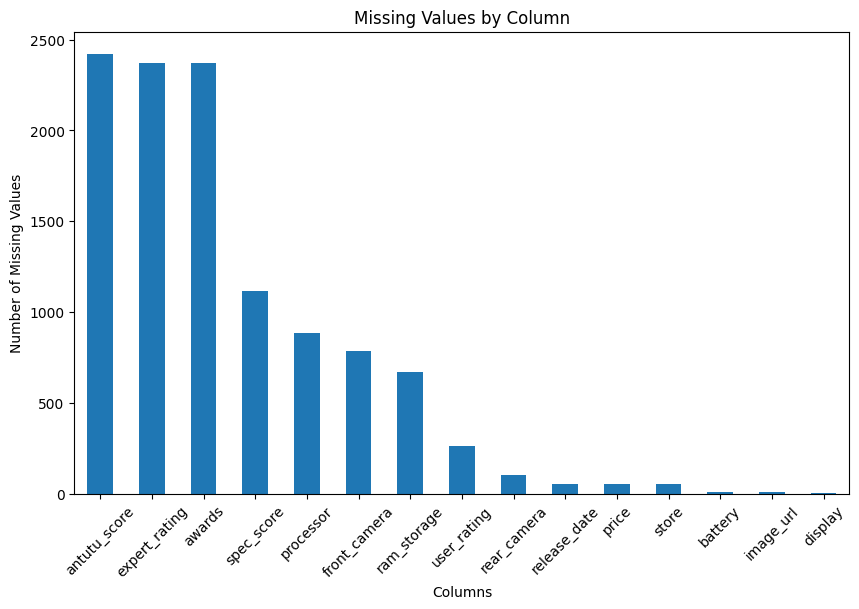

In [7]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(10,6))
missing.plot(kind='bar')

plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)

plt.show()

In [8]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [9]:
data = df.copy()

data = data.drop(columns=['url', 'image_url'])

print("Columns after removing unnecessary fields:")
print(data.columns.tolist())

Columns after removing unnecessary fields:
['name', 'release_date', 'spec_score', 'processor', 'ram_storage', 'rear_camera', 'front_camera', 'battery', 'display', 'antutu_score', 'awards', 'user_rating', 'expert_rating', 'price', 'store']


In [10]:
data['brand'] = data['name'].str.split().str[0]

data[['name', 'brand']].head(10)

,name,brand
0,Xiaomi Redmi Turbo 5,Xiaomi
1,vivo X300 FE,vivo
2,OnePlus Nord CE 6 Lite 5G,OnePlus
3,Motorola Edge 70 Fusion,Motorola
4,OnePlus N6 5G,OnePlus
5,vivo T5 Pro,vivo
6,OnePlus Nord 6,OnePlus
7,vivo T5x,vivo
8,Samsung Galaxy M47 5G,Samsung
9,OPPO Reno16 5G,OPPO


In [11]:

data['release_date'] = (
    data['release_date']
    .astype(str)
    .str.replace('Release Date:', '', regex=False)
    .str.strip()
)

print(data['release_date'].head(20).to_string())

0     19 Jun, 2026
1     06 May, 2026
2     11 May, 2026
3     12 Mar, 2026
4     04 Jul, 2026
5     21 Apr, 2026
6     09 Apr, 2026
7     17 Mar, 2026
8     04 Jul, 2026
9     09 Jul, 2026
10             nan
11    12 Mar, 2025
12    17 Jun, 2026
13    19 Mar, 2025
14             nan
15    09 Apr, 2026
16    30 Apr, 2025
17    08 Jun, 2026
18    09 Apr, 2025
19    29 Apr, 2026


In [12]:
data['price_inr'] = (
    data['price']
    .str.replace('₹', '', regex=False)
    .str.replace(',', '', regex=False)
)

data['price_inr'] = pd.to_numeric(
    data['price_inr'],
    errors='coerce'
)

data[['price', 'price_inr']].head(10)

,price,price_inr
0,"₹37,999",37999.0
1,"₹86,999",86999.0
2,"₹23,999",23999.0
3,"₹26,229",26229.0
4,"₹19,999",19999.0
5,"₹33,500",33500.0
6,"₹39,999",39999.0
7,"₹24,849",24849.0
8,"₹23,999",23999.0
9,"₹61,999",61999.0


In [13]:
data['spec_score'] = pd.to_numeric(
    data['spec_score']
    .str.extract(r'(\d+(?:\.\d+)?)')[0],
    errors='coerce'
)

data[['name', 'spec_score']].head()

,name,spec_score
0,Xiaomi Redmi Turbo 5,89.0
1,vivo X300 FE,95.0
2,OnePlus Nord CE 6 Lite 5G,79.0
3,Motorola Edge 70 Fusion,85.0
4,OnePlus N6 5G,77.0


In [14]:
data['ram_gb'] = pd.to_numeric(
    data['ram_storage'].str.extract(r'(\d+)\s*GB RAM')[0],
    errors='coerce'
)

data['storage_gb'] = pd.to_numeric(
    data['ram_storage'].str.extract(r'\|\s*(\d+)\s*GB Storage')[0],
    errors='coerce'
)

data[['ram_storage', 'ram_gb', 'storage_gb']].head(10)

,ram_storage,ram_gb,storage_gb
0,8 GB RAM | 256 GB Storage,8.0,256.0
1,12 GB RAM | 256 GB Storage,12.0,256.0
2,6 GB RAM | 128 GB Storage,6.0,128.0
3,8 GB RAM | 128 GB Storage,8.0,128.0
4,4 GB RAM | 128 GB Storage,4.0,128.0
5,8 GB RAM | 128 GB Storage,8.0,128.0
6,8 GB RAM | 256 GB Storage,8.0,256.0
7,6 GB RAM | 128 GB Storage,6.0,128.0
8,6 GB RAM | 128 GB Storage,6.0,128.0
9,8 GB RAM | 256 GB Storage,8.0,256.0


In [15]:
data['battery_mah'] = pd.to_numeric(
    data['battery'].str.extract(r'(\d+)\s*mAh')[0],
    errors='coerce'
)

data[['battery', 'battery_mah']].head()

,battery,battery_mah
0,7540 mAh | 100W Hyper Charging,7540.0
1,6500 mAh | 90W Flash Charging,6500.0
2,7000 mAh | 45W Super VOOC Charging,7000.0
3,7000 mAh | 68W Turbo Power Charging,7000.0
4,8000 mAh | 45W Super Charging,8000.0


In [16]:
data['display_inches'] = pd.to_numeric(
    data['display'].str.extract(r'(\d+(?:\.\d+)?)\s*inches')[0],
    errors='coerce'
)

data[['display', 'display_inches']].head()

,display,display_inches
0,6.59 inches (16.74 cm) | AMOLED,6.59
1,6.31 inches (16.03 cm) | AMOLED,6.31
2,6.72 inches (17.07 cm) | LCD,6.72
3,6.8 inches (17.27 cm) | Extreme AMOLED,6.80
4,6.8 inches (17.27 cm) | LCD,6.80


In [17]:
data['antutu_score_num'] = pd.to_numeric(
    data['antutu_score']
    .str.replace(',', '', regex=False)
    .str.extract(r'(\d+)')[0],
    errors='coerce'
)

data[['antutu_score', 'antutu_score_num']].head()

,antutu_score,antutu_score_num
0,"AnTuTu Score 2,135,669",2135669.0
1,"AnTuTu Score 3,000,897",3000897.0
2,"AnTuTu Score 1,015,733",1015733.0
3,"AnTuTu Score 1,149,292",1149292.0
4,"AnTuTu Score 588,319",588319.0


In [18]:
data['rear_camera_mp'] = pd.to_numeric(
    data['rear_camera'].str.extract(r'(\d+(?:\.\d+)?)\s*MP')[0],
    errors='coerce'
)

data['front_camera_mp'] = pd.to_numeric(
    data['front_camera'].str.extract(r'(\d+(?:\.\d+)?)\s*MP')[0],
    errors='coerce'
)

data[['rear_camera', 'rear_camera_mp',
      'front_camera', 'front_camera_mp']].head()

,rear_camera,rear_camera_mp,front_camera,front_camera_mp
0,50 MP + 8 MP Rear Camera,50.0,20 MP Front Camera,20.0
1,50 MP + 50 MP + 8 MP Rear Camera,50.0,50 MP Front Camera,50.0
2,50 MP + 2 MP Rear Camera,50.0,8 MP Front Camera,8.0
3,50 MP + 13 MP Rear Camera,50.0,32 MP Front Camera,32.0
4,50 MP Rear Camera,50.0,8 MP Front Camera,8.0


In [19]:
def convert_rating(series):
    value = pd.to_numeric(
        series.astype(str).str.extract(r'(\d+(?:\.\d+)?)')[0],
        errors='coerce'
    )

    denominator = pd.to_numeric(
        series.astype(str).str.extract(r'/\s*(\d+(?:\.\d+)?)')[0],
        errors='coerce'
    )

    return np.where(
        denominator.notna(),
        value / denominator * 10,
        value
    )

data['user_rating_10'] = convert_rating(data['user_rating'])
data['expert_rating_10'] = convert_rating(data['expert_rating'])

data[['user_rating', 'user_rating_10',
      'expert_rating', 'expert_rating_10']].head(10)

,user_rating,user_rating_10,expert_rating,expert_rating_10
0,8.4/10,8.4,NaN,NaN
1,4.6/5,9.2,8.4/10,8.4
2,4.3/5,8.6,8.2/10,8.2
3,4.4/5,8.8,8.3/10,8.3
4,NaN,NaN,NaN,NaN
5,4.5/5,9.0,8.5/10,8.5
6,4.4/5,8.8,8.4/10,8.4
7,4.4/5,8.8,NaN,NaN
8,NaN,NaN,NaN,NaN
9,8.1/10,8.1,NaN,NaN


In [20]:
data.head()

,name,release_date,spec_score,processor,ram_storage,rear_camera,front_camera,battery,display,antutu_score,...,price_inr,ram_gb,storage_gb,battery_mah,display_inches,antutu_score_num,rear_camera_mp,front_camera_mp,user_rating_10,expert_rating_10
0,Xiaomi Redmi Turbo 5,"19 Jun, 2026",89.0,MediaTek Dimensity 8500 Ultra,8 GB RAM | 256 GB Storage,50 MP + 8 MP Rear Camera,20 MP Front Camera,7540 mAh | 100W Hyper Charging,6.59 inches (16.74 cm) | AMOLED,"AnTuTu Score 2,135,669",...,37999.0,8.0,256.0,7540.0,6.59,2135669.0,50.0,20.0,8.4,NaN
1,vivo X300 FE,"06 May, 2026",95.0,Snapdragon 8 Gen 5,12 GB RAM | 256 GB Storage,50 MP + 50 MP + 8 MP Rear Camera,50 MP Front Camera,6500 mAh | 90W Flash Charging,6.31 inches (16.03 cm) | AMOLED,"AnTuTu Score 3,000,897",...,86999.0,12.0,256.0,6500.0,6.31,3000897.0,50.0,50.0,9.2,8.4
2,OnePlus Nord CE 6 Lite 5G,"11 May, 2026",79.0,MediaTek Dimensity 7400 Apex,6 GB RAM | 128 GB Storage,50 MP + 2 MP Rear Camera,8 MP Front Camera,7000 mAh | 45W Super VOOC Charging,6.72 inches (17.07 cm) | LCD,"AnTuTu Score 1,015,733",...,23999.0,6.0,128.0,7000.0,6.72,1015733.0,50.0,8.0,8.6,8.2
3,Motorola Edge 70 Fusion,"12 Mar, 2026",85.0,Snapdragon 7s Gen 4,8 GB RAM | 128 GB Storage,50 MP + 13 MP Rear Camera,32 MP Front Camera,7000 mAh | 68W Turbo Power Charging,6.8 inches (17.27 cm) | Extreme AMOLED,"AnTuTu Score 1,149,292",...,26229.0,8.0,128.0,7000.0,6.80,1149292.0,50.0,32.0,8.8,8.3
4,OnePlus N6 5G,"04 Jul, 2026",77.0,MediaTek Dimensity 6360 Apex,4 GB RAM | 128 GB Storage,50 MP Rear Camera,8 MP Front Camera,8000 mAh | 45W Super Charging,6.8 inches (17.27 cm) | LCD,"AnTuTu Score 588,319",...,19999.0,4.0,128.0,8000.0,6.80,588319.0,50.0,8.0,NaN,NaN


In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              4000 non-null   object 
 1   release_date      4000 non-null   object 
 2   spec_score        2884 non-null   float64
 3   processor         3117 non-null   object 
 4   ram_storage       3331 non-null   object 
 5   rear_camera       3896 non-null   object 
 6   front_camera      3212 non-null   object 
 7   battery           3989 non-null   object 
 8   display           3997 non-null   object 
 9   antutu_score      1577 non-null   object 
 10  awards            1631 non-null   object 
 11  user_rating       3736 non-null   object 
 12  expert_rating     1627 non-null   object 
 13  price             3947 non-null   object 
 14  store             3947 non-null   object 
 15  brand             4000 non-null   object 
 16  price_inr         3947 non-null   float64


In [22]:
quality_report = pd.DataFrame({
    'Column': data.columns,
    'Data Type': data.dtypes.astype(str).values,
    'Missing Values': data.isnull().sum().values,
    'Missing %': (data.isnull().mean() * 100).round(2).values,
    'Unique Values': data.nunique().values
})

quality_report

,Column,Data Type,Missing Values,Missing %,Unique Values
0,name,object,0,0.00,4000
1,release_date,object,0,0.00,1800
2,spec_score,float64,1116,27.90,48
3,processor,object,883,22.08,348
4,ram_storage,object,669,16.73,82
5,rear_camera,object,104,2.60,261
6,front_camera,object,788,19.70,57
7,battery,object,11,0.27,703
8,display,object,3,0.08,372
9,antutu_score,object,2423,60.58,854


In [23]:
numeric_columns = [
    'price_inr',
    'spec_score',
    'ram_gb',
    'storage_gb',
    'battery_mah',
    'display_inches',
    'antutu_score_num',
    'rear_camera_mp',
    'front_camera_mp',
    'user_rating_10',
    'expert_rating_10'
]

for col in numeric_columns:
    data[col] = data[col].fillna(data[col].median())

print("Missing values after numerical cleaning:")
print(data[numeric_columns].isnull().sum())

Missing values after numerical cleaning:
price_inr           0
spec_score          0
ram_gb              0
storage_gb          0
battery_mah         0
display_inches      0
antutu_score_num    0
rear_camera_mp      0
front_camera_mp     0
user_rating_10      0
expert_rating_10    0
dtype: int64


In [24]:
data.to_csv('mobiles_cleaned.csv', index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [25]:
from google.colab import files

files.download('mobiles_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
data[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
price_inr,4000.0,20721.276250,26674.559761,399.00,5990.0,12999.0,24876.750,219900.0
spec_score,4000.0,77.265750,6.617105,52.00,74.0,77.0,80.000,99.0
ram_gb,4000.0,5.941500,2.967538,0.00,4.0,6.0,8.000,18.0
storage_gb,4000.0,131.539500,102.946882,2.00,64.0,128.0,128.000,512.0
battery_mah,4000.0,4028.570250,1756.678296,300.00,2645.0,4500.0,5000.000,11000.0
display_inches,4000.0,5.438985,1.789925,0.66,5.0,6.5,6.685,8.1
antutu_score_num,4000.0,530840.739500,445225.016392,0.00,448625.0,448625.0,448625.000,4033382.0
rear_camera_mp,4000.0,32.271310,33.026723,0.08,8.0,16.0,50.000,200.0
front_camera_mp,4000.0,13.774650,11.243670,0.30,8.0,10.0,16.000,60.0
user_rating_10,4000.0,8.156500,0.800492,2.00,7.8,8.4,8.600,10.0


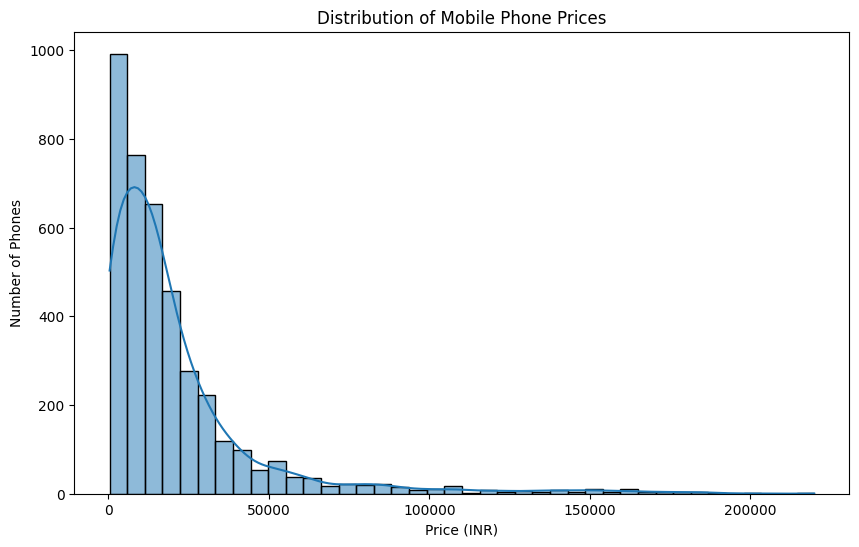

In [27]:
plt.figure(figsize=(10,6))

sns.histplot(data['price_inr'], bins=40, kde=True)

plt.title("Distribution of Mobile Phone Prices")
plt.xlabel("Price (INR)")
plt.ylabel("Number of Phones")

plt.show()

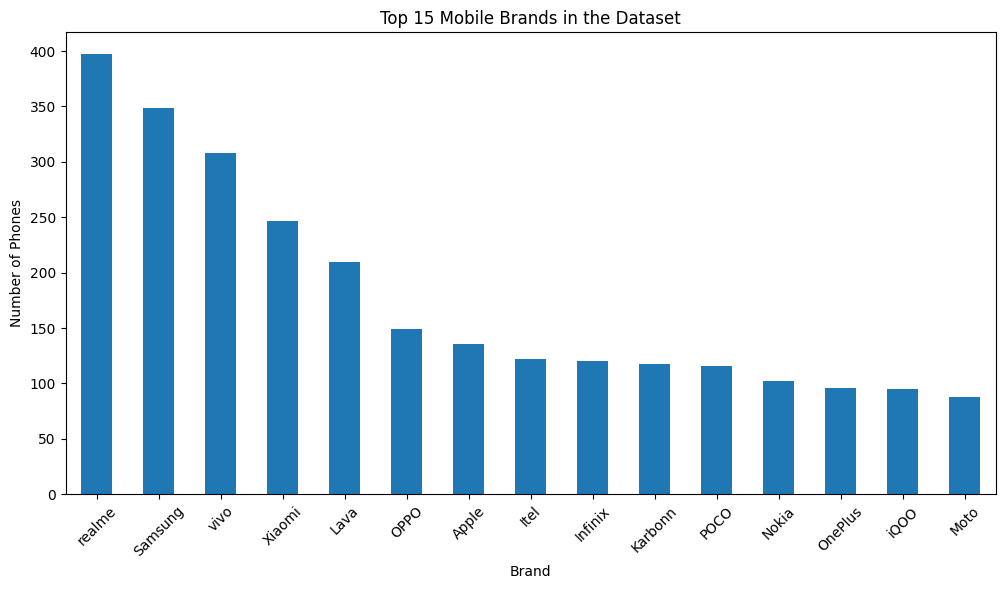

In [28]:
brand_counts = data['brand'].value_counts().head(15)

plt.figure(figsize=(12,6))

brand_counts.plot(kind='bar')

plt.title("Top 15 Mobile Brands in the Dataset")
plt.xlabel("Brand")
plt.ylabel("Number of Phones")
plt.xticks(rotation=45)

plt.show()

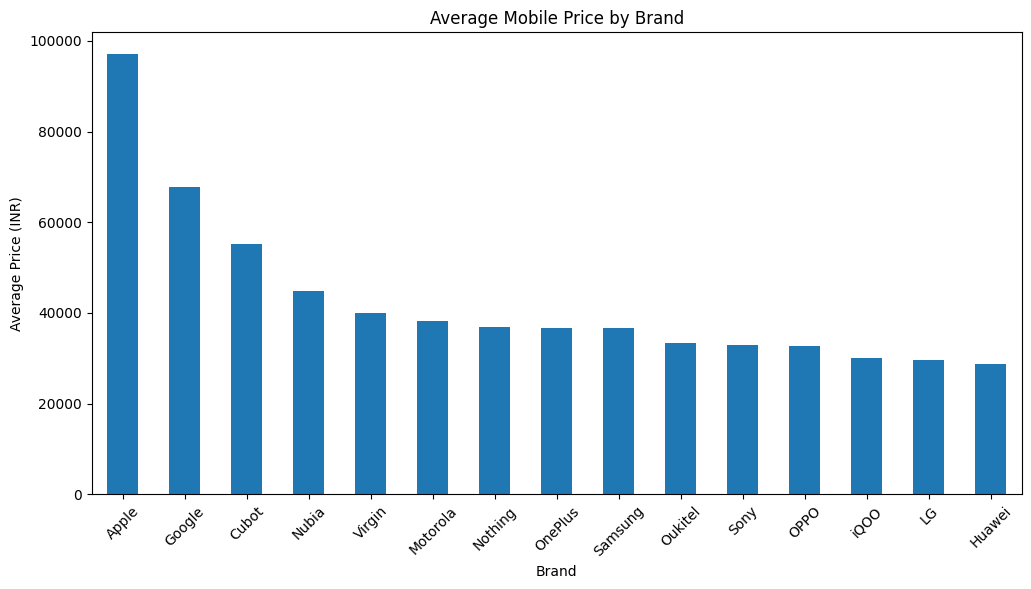

In [29]:
brand_price = (
    data.groupby('brand')['price_inr']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,6))

brand_price.plot(kind='bar')

plt.title("Average Mobile Price by Brand")
plt.xlabel("Brand")
plt.ylabel("Average Price (INR)")
plt.xticks(rotation=45)

plt.show()

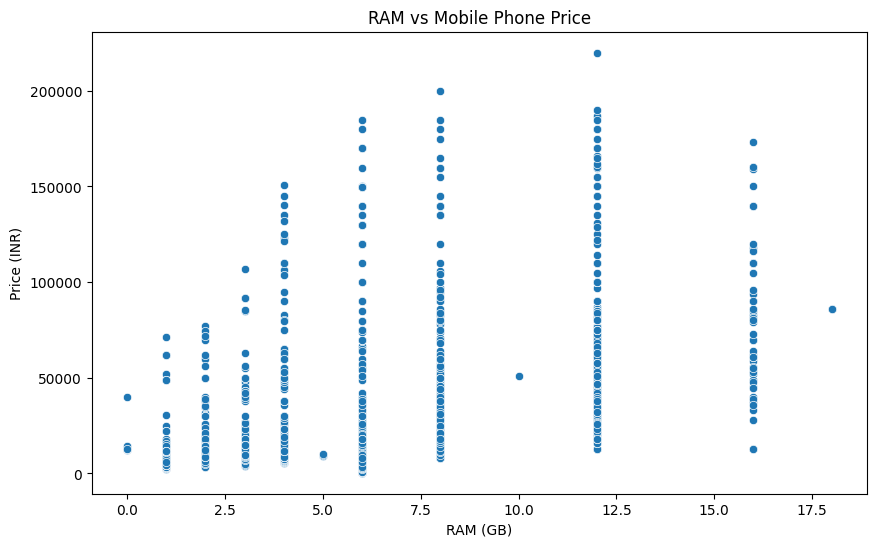

In [30]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=data,
    x='ram_gb',
    y='price_inr'
)

plt.title("RAM vs Mobile Phone Price")
plt.xlabel("RAM (GB)")
plt.ylabel("Price (INR)")

plt.show()

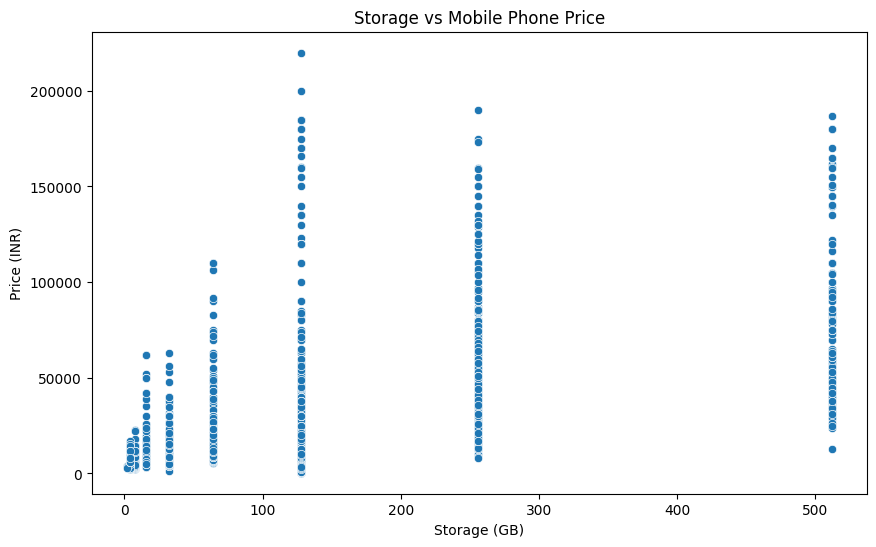

In [31]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=data,
    x='storage_gb',
    y='price_inr'
)

plt.title("Storage vs Mobile Phone Price")
plt.xlabel("Storage (GB)")
plt.ylabel("Price (INR)")

plt.show()

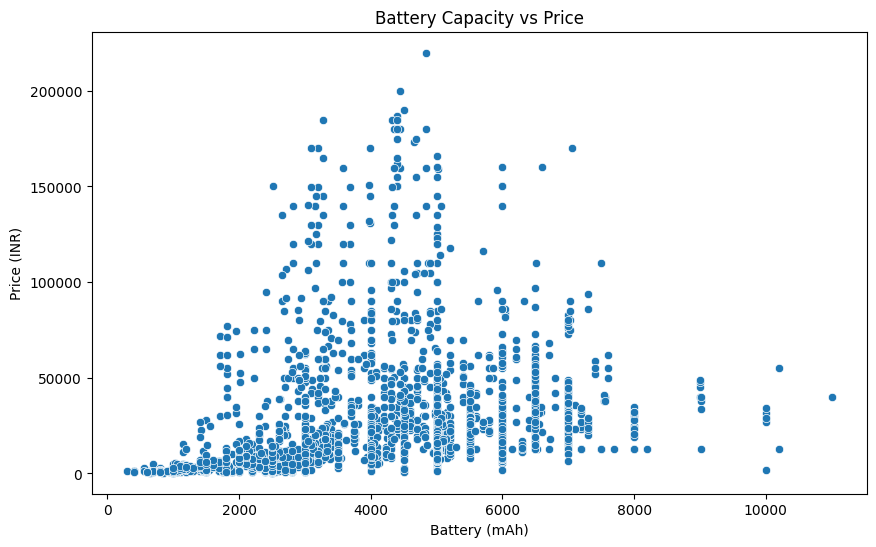

In [32]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=data,
    x='battery_mah',
    y='price_inr'
)

plt.title("Battery Capacity vs Price")
plt.xlabel("Battery (mAh)")
plt.ylabel("Price (INR)")

plt.show()

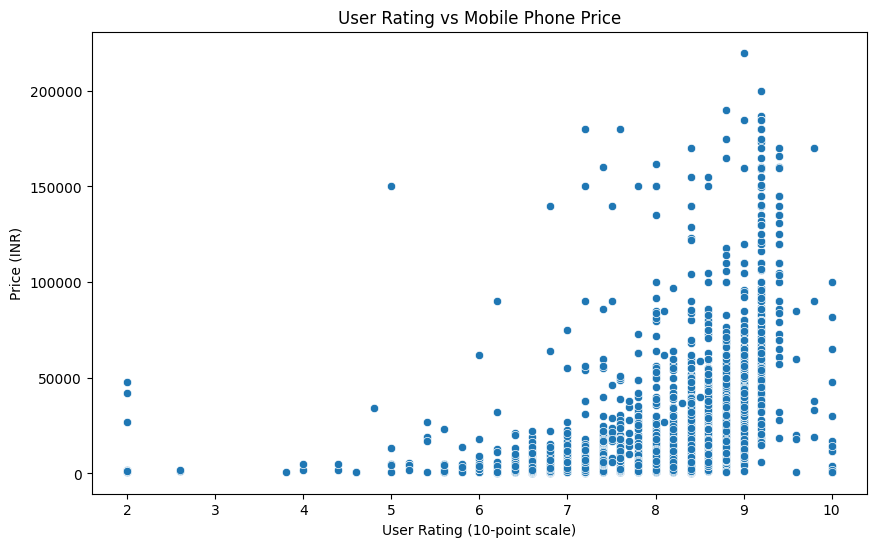

In [33]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=data,
    x='user_rating_10',
    y='price_inr'
)

plt.title("User Rating vs Mobile Phone Price")
plt.xlabel("User Rating (10-point scale)")
plt.ylabel("Price (INR)")

plt.show()

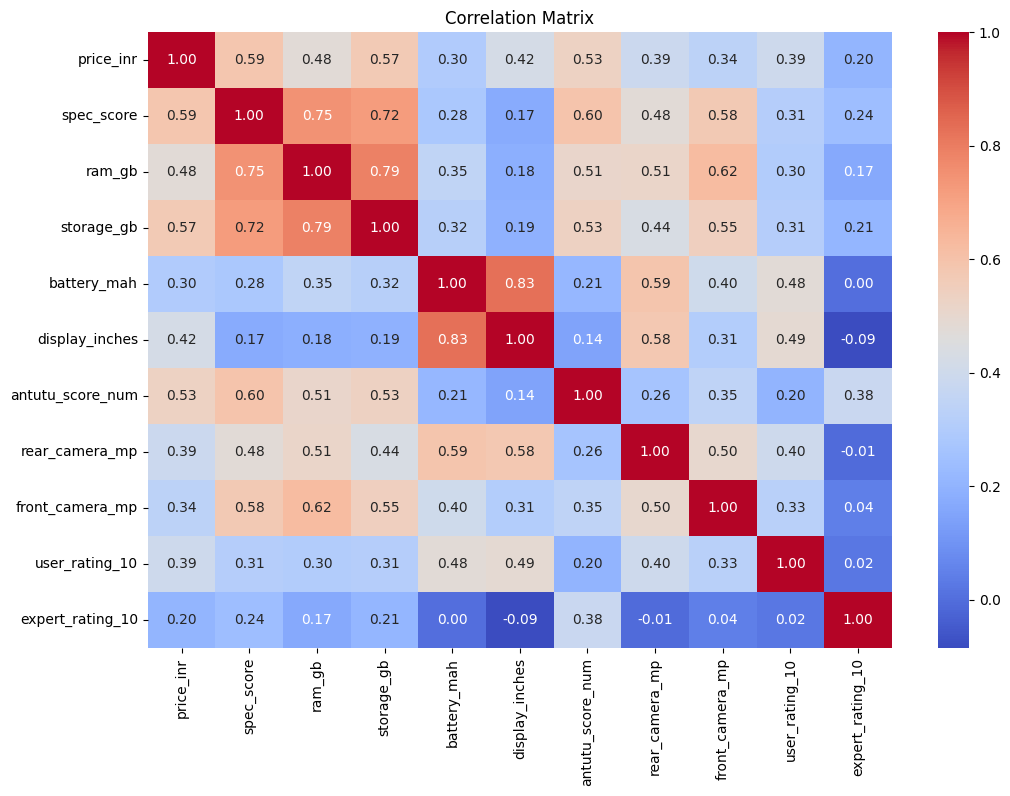

In [34]:
correlation_columns = [
    'price_inr',
    'spec_score',
    'ram_gb',
    'storage_gb',
    'battery_mah',
    'display_inches',
    'antutu_score_num',
    'rear_camera_mp',
    'front_camera_mp',
    'user_rating_10',
    'expert_rating_10'
]

correlation_matrix = data[correlation_columns].corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")

plt.show()

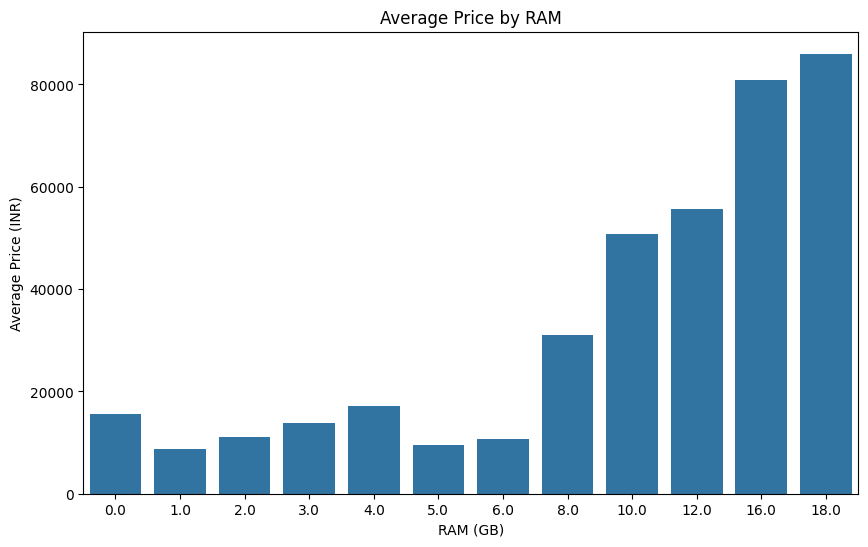

In [35]:
ram_price = (
    data.groupby('ram_gb')['price_inr']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=ram_price,
    x='ram_gb',
    y='price_inr'
)

plt.title("Average Price by RAM")
plt.xlabel("RAM (GB)")
plt.ylabel("Average Price (INR)")

plt.show()

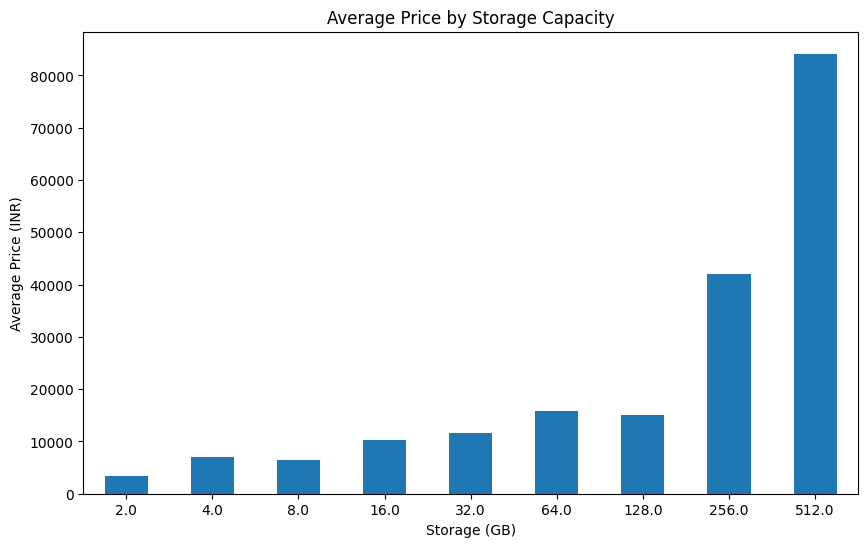

In [36]:
storage_price = (
    data.groupby('storage_gb')['price_inr']
    .mean()
    .sort_index()
)

plt.figure(figsize=(10,6))

storage_price.plot(kind='bar')

plt.title("Average Price by Storage Capacity")
plt.xlabel("Storage (GB)")
plt.ylabel("Average Price (INR)")
plt.xticks(rotation=0)

plt.show()

In [37]:
def price_category(price):
    if price < 15000:
        return 'Budget'
    elif price < 30000:
        return 'Mid-range'
    elif price < 60000:
        return 'Upper Mid-range'
    else:
        return 'Premium'

data['price_category'] = data['price_inr'].apply(price_category)

data['price_category'].value_counts()

,count
price_category,
Budget,2266
Mid-range,1011
Upper Mid-range,468
Premium,255


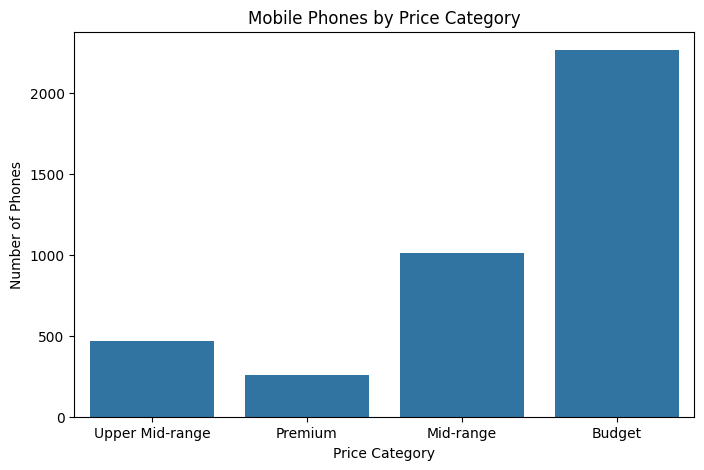

In [38]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=data,
    x='price_category'
)

plt.title("Mobile Phones by Price Category")
plt.xlabel("Price Category")
plt.ylabel("Number of Phones")

plt.show()

In [39]:
features = [
    'brand',
    'processor',
    'spec_score',
    'ram_gb',
    'storage_gb',
    'battery_mah',
    'display_inches',
    'antutu_score_num',
    'rear_camera_mp',
    'front_camera_mp',
    'user_rating_10',
    'expert_rating_10'
]

target = 'price_inr'

X = data[features]
y = data[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (4000, 12)
Target shape: (4000,)


In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 3200
Testing records: 800


In [41]:
categorical_features = [
    'brand',
    'processor'
]

numeric_features = [
    'spec_score',
    'ram_gb',
    'storage_gb',
    'battery_mah',
    'display_inches',
    'antutu_score_num',
    'rear_camera_mp',
    'front_camera_mp',
    'user_rating_10',
    'expert_rating_10'
]

In [42]:
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median'))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['spec_score', 'ram_gb', 'storage_gb', 'battery_mah', 'display_inches', 'antutu_score_num', 'rear_camera_mp', 'front_camera_mp', 'user_rating_10', 'expert_rating_10']

Categorical features:
['brand', 'processor']


In [43]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [44]:
model_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ]
)

In [45]:
model_pipeline.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [46]:
y_pred = model_pipeline.predict(X_test)

print("Predictions generated successfully!")
print(y_pred[:10])

Predictions generated successfully!
[ 2843.035        927.54641667 81890.84       45505.91
   914.49466667 48269.79        9950.09       45497.59
 30604.55       10023.01      ]


In [47]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("------------------")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 4))

Model Performance
------------------
MAE : 4041.46
RMSE: 8125.74
R²  : 0.9022


In [48]:
results = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

results.head(10)

,Actual Price,Predicted Price
0,1899.0,2843.035000
1,745.0,927.546417
2,109900.0,81890.840000
3,62000.0,45505.910000
4,1090.0,914.494667
5,39999.0,48269.790000
6,9499.0,9950.090000
7,32999.0,45497.590000
8,34999.0,30604.550000
9,8499.0,10023.010000


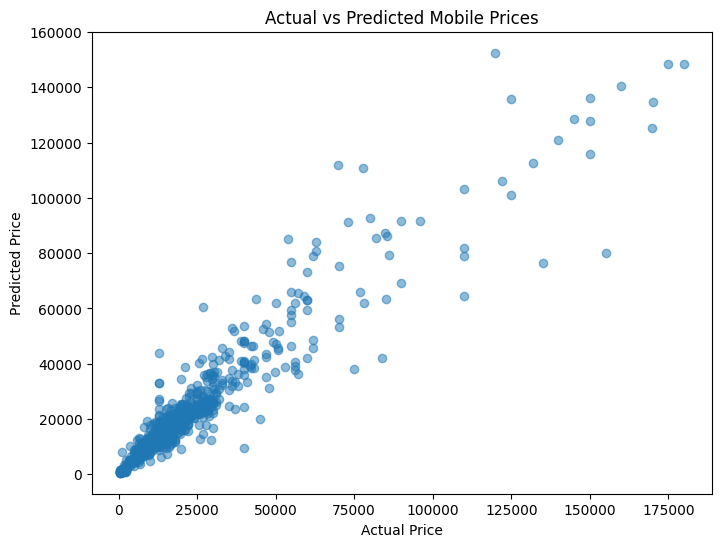

In [49]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Mobile Prices")

plt.show()

In [50]:
def predict_mobile_price(
    brand,
    processor,
    spec_score,
    ram_gb,
    storage_gb,
    battery_mah,
    display_inches,
    antutu_score_num,
    rear_camera_mp,
    front_camera_mp,
    user_rating_10,
    expert_rating_10
):

    phone = pd.DataFrame({
        'brand': [brand],
        'processor': [processor],
        'spec_score': [spec_score],
        'ram_gb': [ram_gb],
        'storage_gb': [storage_gb],
        'battery_mah': [battery_mah],
        'display_inches': [display_inches],
        'antutu_score_num': [antutu_score_num],
        'rear_camera_mp': [rear_camera_mp],
        'front_camera_mp': [front_camera_mp],
        'user_rating_10': [user_rating_10],
        'expert_rating_10': [expert_rating_10]
    })

    prediction = model_pipeline.predict(phone)[0]

    return prediction

In [51]:
predicted_price = predict_mobile_price(
    brand='Xiaomi',
    processor='MediaTek Dimensity 8500 Ultra',
    spec_score=89,
    ram_gb=8,
    storage_gb=256,
    battery_mah=7540,
    display_inches=6.59,
    antutu_score_num=2135669,
    rear_camera_mp=50,
    front_camera_mp=20,
    user_rating_10=8.4,
    expert_rating_10=8.0
)

print("Predicted Mobile Price: ₹", round(predicted_price, 2))

Predicted Mobile Price: ₹ 43756.49


In [52]:
print("MOBILE PHONE ANALYTICS DASHBOARD")
print("----------------------------------")

print("Total Phones:", len(data))

print(
    "Average Price: ₹",
    round(data['price_inr'].mean(), 2)
)

print(
    "Minimum Price: ₹",
    round(data['price_inr'].min(), 2)
)

print(
    "Maximum Price: ₹",
    round(data['price_inr'].max(), 2)
)

print(
    "Number of Brands:",
    data['brand'].nunique()
)

MOBILE PHONE ANALYTICS DASHBOARD
----------------------------------
Total Phones: 4000
Average Price: ₹ 20721.28
Minimum Price: ₹ 399.0
Maximum Price: ₹ 219900.0
Number of Brands: 118


In [53]:
top_rated = (
    data[['name', 'brand', 'price_inr', 'user_rating_10']]
    .sort_values('user_rating_10', ascending=False)
    .head(10)
)

top_rated

,name,brand,price_inr,user_rating_10
573,OPPO A6c 4G 128GB,OPPO,16999.0,10.0
504,HMD Touch 4G,HMD,3799.0,10.0
586,Xiaomi 17T 512GB,Xiaomi,64998.0,10.0
1056,I Kall K42 Flip,I,1724.0,10.0
633,Lava Shark 2,Lava,11499.0,10.0
2720,Tork XS,Tork,799.0,10.0
751,vivo X300 512GB,vivo,81999.0,10.0
181,OPPO A6c 4G,OPPO,13999.0,10.0
234,Lava Bold N2 5G,Lava,11999.0,10.0
1692,realme GT 7 Dream Edition,realme,47999.0,10.0


In [54]:
most_expensive = (
    data[['name', 'brand', 'price_inr', 'ram_gb', 'storage_gb']]
    .sort_values('price_inr', ascending=False)
    .head(10)
)

most_expensive

,name,brand,price_inr,ram_gb,storage_gb
572,Apple iPhone 17 Pro Max 2TB,Apple,219900.0,12.0,128.0
2366,Apple iPhone 15 Pro Max 1TB,Apple,199900.0,8.0,128.0
2956,Samsung Galaxy Z Fold 2,Samsung,189999.0,12.0,256.0
491,Samsung Galaxy Z Fold7 512GB,Samsung,186999.0,12.0,512.0
2379,Samsung Galaxy Z Fold5 1TB,Samsung,184999.0,12.0,128.0
2368,Apple iPhone 15 Pro 1TB,Apple,184900.0,8.0,128.0
2145,Apple iPhone 14 Pro Max 1TB,Apple,184900.0,6.0,128.0
2719,Samsung Galaxy Z Fold 3 512GB,Samsung,179999.0,12.0,512.0
532,Apple iPhone 17 Pro Max 1TB,Apple,179900.0,12.0,128.0
2367,Apple iPhone 15 Pro Max 512GB,Apple,179900.0,8.0,512.0


In [55]:
top_spec = (
    data[['name', 'brand', 'spec_score', 'price_inr']]
    .sort_values('spec_score', ascending=False)
    .head(10)
)

top_spec

,name,brand,spec_score,price_inr
627,Samsung Galaxy S25 Ultra 1TB,Samsung,99.0,165999.0
491,Samsung Galaxy Z Fold7 512GB,Samsung,99.0,186999.0
32,OPPO Find X9 Ultra,OPPO,98.0,169999.0
64,Samsung Galaxy S25 Ultra,Samsung,97.0,84999.0
29,Samsung Galaxy S26 Ultra,Samsung,97.0,124999.0
59,vivo X300 Ultra,vivo,97.0,159999.0
745,Samsung Galaxy S25 Ultra 512GB,Samsung,97.0,99999.0
209,Samsung Galaxy S25 Plus,Samsung,97.0,71500.0
157,vivo X300 Pro,vivo,97.0,109999.0
1838,Samsung Galaxy S25 Plus 512GB,Samsung,97.0,83999.0


In [56]:
summary = pd.DataFrame({
    'Metric': [
        'Total Phones',
        'Total Brands',
        'Average Price',
        'Minimum Price',
        'Maximum Price',
        'Average RAM',
        'Average Storage',
        'Average Battery'
    ],

    'Value': [
        len(data),
        data['brand'].nunique(),
        round(data['price_inr'].mean(), 2),
        round(data['price_inr'].min(), 2),
        round(data['price_inr'].max(), 2),
        round(data['ram_gb'].mean(), 2),
        round(data['storage_gb'].mean(), 2),
        round(data['battery_mah'].mean(), 2)
    ]
})

summary

,Metric,Value
0,Total Phones,4000.00
1,Total Brands,118.00
2,Average Price,20721.28
3,Minimum Price,399.00
4,Maximum Price,219900.00
5,Average RAM,5.94
6,Average Storage,131.54
7,Average Battery,4028.57


In [57]:
powerbi_data = data.copy()

powerbi_data.to_csv(
    'mobile_powerbi_data.csv',
    index=False
)

print("Power BI dataset created successfully!")
print("Rows:", powerbi_data.shape[0])
print("Columns:", powerbi_data.shape[1])

Power BI dataset created successfully!
Rows: 4000
Columns: 27


In [58]:
from google.colab import files

files.download('mobile_powerbi_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [59]:
import joblib

joblib.dump(model, "model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [60]:
import sklearn
print(sklearn.__version__)

1.9.1


In [61]:
!pip install scikit-learn==1.9.1

In [62]:
import sklearn
print("Current scikit-learn version:", sklearn.__version__)

Current scikit-learn version: 1.9.1
